In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pprint
import pyspark
import pyspark.sql.functions as F

from pyspark.sql.functions import col
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

import utils.data_processing_bronze_table
import utils.data_processing_silver_table
import utils.data_processing_gold_table

## Set up PySpark Session

In [2]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/12 07:14:25 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/12 07:14:25 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


## Set Up Config

In [3]:
# set up config
snapshot_date_str = "2023-01-01"

start_date_str = "2023-01-01"
end_date_str = "2024-12-01"

In [4]:
# generate list of dates to process
def generate_first_of_month_dates(start_date_str, end_date_str):
    # Convert the date strings to datetime objects
    start_date = datetime.strptime(start_date_str, "%Y-%m-%d")
    end_date = datetime.strptime(end_date_str, "%Y-%m-%d")
    
    # List to store the first of month dates
    first_of_month_dates = []

    # Start from the first of the month of the start_date
    current_date = datetime(start_date.year, start_date.month, 1)

    while current_date <= end_date:
        # Append the date in yyyy-mm-dd format
        first_of_month_dates.append(current_date.strftime("%Y-%m-%d"))
        
        # Move to the first of the next month
        if current_date.month == 12:
            current_date = datetime(current_date.year + 1, 1, 1)
        else:
            current_date = datetime(current_date.year, current_date.month + 1, 1)

    return first_of_month_dates

dates_str_lst = generate_first_of_month_dates(start_date_str, end_date_str)
dates_str_lst

['2023-01-01',
 '2023-02-01',
 '2023-03-01',
 '2023-04-01',
 '2023-05-01',
 '2023-06-01',
 '2023-07-01',
 '2023-08-01',
 '2023-09-01',
 '2023-10-01',
 '2023-11-01',
 '2023-12-01',
 '2024-01-01',
 '2024-02-01',
 '2024-03-01',
 '2024-04-01',
 '2024-05-01',
 '2024-06-01',
 '2024-07-01',
 '2024-08-01',
 '2024-09-01',
 '2024-10-01',
 '2024-11-01',
 '2024-12-01']

## Build Silver Table for Lms

In [5]:
bronze_lms_directory = "datamart/bronze/lms/"
bronze_fin_directory = "datamart/bronze/financial/"
bronze_attr_directory = "datamart/bronze/attributes/"
bronze_click_directory = "datamart/bronze/clickstream/"

In [6]:
# create silver datalake for lms_loan
silver_loan_daily_directory = "datamart/silver/lms_loan_daily/"

if not os.path.exists(silver_loan_daily_directory):
    os.makedirs(silver_loan_daily_directory)

In [7]:
# run silver backfill
for date_str in dates_str_lst:
    utils.data_processing_silver_table.process_silver_table_lms(date_str, bronze_lms_directory, silver_loan_daily_directory, spark)

loaded from: datamart/bronze/lms/bronze_lms_loan_daily_2023_01_01.csv row count: 530


saved to: datamart/silver/lms_loan_daily/silver_loan_daily_2023_01_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_loan_daily_2023_02_01.csv row count: 1031


saved to: datamart/silver/lms_loan_daily/silver_loan_daily_2023_02_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_loan_daily_2023_03_01.csv row count: 1537
saved to: datamart/silver/lms_loan_daily/silver_loan_daily_2023_03_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_loan_daily_2023_04_01.csv row count: 2047
saved to: datamart/silver/lms_loan_daily/silver_loan_daily_2023_04_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_loan_daily_2023_05_01.csv row count: 2568
saved to: datamart/silver/lms_loan_daily/silver_loan_daily_2023_05_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_loan_daily_2023_06_01.csv row count: 3085


saved to: datamart/silver/lms_loan_daily/silver_loan_daily_2023_06_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_loan_daily_2023_07_01.csv row count: 3556
saved to: datamart/silver/lms_loan_daily/silver_loan_daily_2023_07_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_loan_daily_2023_08_01.csv row count: 4037


saved to: datamart/silver/lms_loan_daily/silver_loan_daily_2023_08_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_loan_daily_2023_09_01.csv row count: 4491
saved to: datamart/silver/lms_loan_daily/silver_loan_daily_2023_09_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_loan_daily_2023_10_01.csv row count: 4978
saved to: datamart/silver/lms_loan_daily/silver_loan_daily_2023_10_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_loan_daily_2023_11_01.csv row count: 5469


...

saved to: datamart/silver/lms_loan_daily/silver_loan_daily_2024_02_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_loan_daily_2024_03_01.csv row count: 5425
saved to: datamart/silver/lms_loan_daily/silver_loan_daily_2024_03_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_loan_daily_2024_04_01.csv row count: 5417
saved to: datamart/silver/lms_loan_daily/silver_loan_daily_2024_04_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_loan_daily_2024_05_01.csv row count: 5391


saved to: datamart/silver/lms_loan_daily/silver_loan_daily_2024_05_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_loan_daily_2024_06_01.csv row count: 5418


saved to: datamart/silver/lms_loan_daily/silver_loan_daily_2024_06_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_loan_daily_2024_07_01.csv row count: 5442
saved to: datamart/silver/lms_loan_daily/silver_loan_daily_2024_07_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_loan_daily_2024_08_01.csv row count: 5531


saved to: datamart/silver/lms_loan_daily/silver_loan_daily_2024_08_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_loan_daily_2024_09_01.csv row count: 5537
saved to: datamart/silver/lms_loan_daily/silver_loan_daily_2024_09_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_loan_daily_2024_10_01.csv row count: 5502
saved to: datamart/silver/lms_loan_daily/silver_loan_daily_2024_10_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_loan_daily_2024_11_01.csv row count: 5501


saved to: datamart/silver/lms_loan_daily/silver_loan_daily_2024_11_01.parquet
loaded from: datamart/bronze/lms/bronze_lms_loan_daily_2024_12_01.csv row count: 5531
saved to: datamart/silver/lms_loan_daily/silver_loan_daily_2024_12_01.parquet


In [8]:
utils.data_processing_silver_table.process_silver_table_lms(date_str, bronze_lms_directory, silver_loan_daily_directory, spark).toPandas()

loaded from: datamart/bronze/lms/bronze_lms_loan_daily_2024_12_01.csv row count: 5531


saved to: datamart/silver/lms_loan_daily/silver_loan_daily_2024_12_01.parquet


,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date,mob,installments_missed,first_missed_date,dpd
0,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,9,10000.0,1000.0,1000.0,0.0,1000.0,2024-12-01,9,0,None,0
1,CUS_0x102e_2024_04_01,CUS_0x102e,2024-04-01,10,8,10000.0,1000.0,0.0,6000.0,8000.0,2024-12-01,8,6,2024-06-01,183
2,CUS_0x1038_2024_10_01,CUS_0x1038,2024-10-01,10,2,10000.0,1000.0,1000.0,0.0,8000.0,2024-12-01,2,0,None,0
3,CUS_0x103e_2024_12_01,CUS_0x103e,2024-12-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2024-12-01,0,0,None,0
4,CUS_0x1048_2024_02_01,CUS_0x1048,2024-02-01,10,10,10000.0,1000.0,0.0,9000.0,9000.0,2024-12-01,10,9,2024-03-01,275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5526,CUS_0xfe3_2024_04_01,CUS_0xfe3,2024-04-01,10,8,10000.0,1000.0,1000.0,0.0,2000.0,2024-12-01,8,0,None,0
5527,CUS_0xff3_2024_06_01,CUS_0xff3,2024-06-01,10,6,10000.0,1000.0,1000.0,0.0,4000.0,2024-12-01,6,0,None,0
5528,CUS_0xff4_2024_12_01,CUS_0xff4,2024-12-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2024-12-01,0,0,None,0
5529,CUS_0xff6_2024_10_01,CUS_0xff6,2024-10-01,10,2,10000.0,1000.0,1000.0,0.0,8000.0,2024-12-01,2,0,None,0


## EDA on Credit Labels

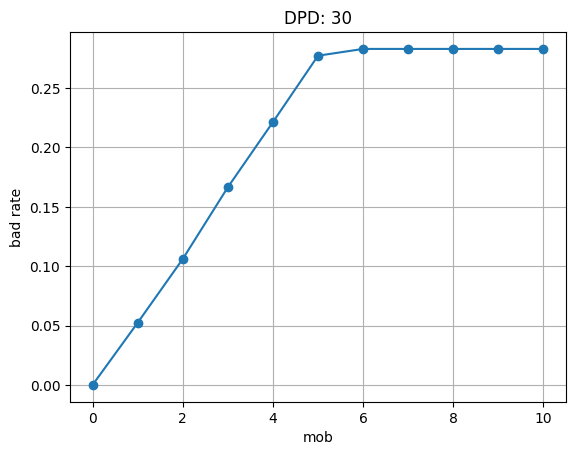

In [9]:
# set dpd label definition
dpd = 30

# Path to the folder containing CSV files
folder_path = silver_loan_daily_directory

# Read all CSV files into a single DataFrame
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)

# filter only completed loans
df = df.filter(col("loan_start_date") < datetime.strptime("2024-01-01", "%Y-%m-%d"))

# create dpd flag if more than dpd
df = df.withColumn("dpd_flag", F.when(col("dpd") >= dpd, 1).otherwise(0))

# actual bads 
actual_bads_df = df.filter(col("installment_num") == 10)

# prepare for analysis
# df = df.filter(col("installment_num") < 10)

# visualise bad rate
pdf = df.toPandas()

# Group by col_A and count occurrences in col_B
grouped = pdf.groupby('mob')['dpd_flag'].mean()

# Sort the index (x-axis) of the grouped DataFrame
grouped = grouped.sort_index()

# Plotting
grouped.plot(kind='line', marker='o')

plt.title('DPD: '+ str(dpd))
plt.xlabel('mob')
plt.ylabel('bad rate')
plt.grid(True)
plt.show()


In [10]:
df.show()

+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+--------+
|             loan_id|Customer_ID|loan_start_date|tenure|installment_num|loan_amt|due_amt|paid_amt|overdue_amt|balance|snapshot_date|mob|installments_missed|first_missed_date|dpd|dpd_flag|
+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+--------+
|CUS_0x1011_2023_1...| CUS_0x1011|     2023-11-01|    10|             10| 10000.0| 1000.0|  1000.0|        0.0|    0.0|   2024-09-01| 10|                  0|             NULL|  0|       0|
|CUS_0x1013_2023_1...| CUS_0x1013|     2023-12-01|    10|              9| 10000.0| 1000.0|  1000.0|        0.0| 1000.0|   2024-09-01|  9|                  0|             NULL|  0|       0|
|CUS_0x1018_2023_1...| CUS_0x1018|     2023-11-01|    1

## Build Silver Table for Financial

In [11]:
# create silver datalake for financial
silver_fin_directory = "datamart/silver/financial/"

if not os.path.exists(silver_fin_directory):
    os.makedirs(silver_fin_directory)

In [12]:
# run silver backfill
for date_str in dates_str_lst:
    utils.data_processing_silver_table.process_silver_table_financial(date_str, bronze_fin_directory, silver_fin_directory, spark)

loaded from: datamart/bronze/financial/bronze_features_financials_2023_01_01.csv row count: 530


saved to: datamart/silver/financial/silver_financial_2023_01_01.parquet
loaded from: datamart/bronze/financial/bronze_features_financials_2023_02_01.csv row count: 501


saved to: datamart/silver/financial/silver_financial_2023_02_01.parquet
loaded from: datamart/bronze/financial/bronze_features_financials_2023_03_01.csv row count: 506


saved to: datamart/silver/financial/silver_financial_2023_03_01.parquet
loaded from: datamart/bronze/financial/bronze_features_financials_2023_04_01.csv row count: 510
saved to: datamart/silver/financial/silver_financial_2023_04_01.parquet
loaded from: datamart/bronze/financial/bronze_features_financials_2023_05_01.csv row count: 521


saved to: datamart/silver/financial/silver_financial_2023_05_01.parquet
loaded from: datamart/bronze/financial/bronze_features_financials_2023_06_01.csv row count: 517
saved to: datamart/silver/financial/silver_financial_2023_06_01.parquet
loaded from: datamart/bronze/financial/bronze_features_financials_2023_07_01.csv row count: 471
saved to: datamart/silver/financial/silver_financial_2023_07_01.parquet
loaded from: datamart/bronze/financial/bronze_features_financials_2023_08_01.csv row count: 481


saved to: datamart/silver/financial/silver_financial_2023_08_01.parquet
loaded from: datamart/bronze/financial/bronze_features_financials_2023_09_01.csv row count: 454
saved to: datamart/silver/financial/silver_financial_2023_09_01.parquet
loaded from: datamart/bronze/financial/bronze_features_financials_2023_10_01.csv row count: 487


saved to: datamart/silver/financial/silver_financial_2023_10_01.parquet
loaded from: datamart/bronze/financial/bronze_features_financials_2023_11_01.csv row count: 491
saved to: datamart/silver/financial/silver_financial_2023_11_01.parquet
loaded from: datamart/bronze/financial/bronze_features_financials_2023_12_01.csv row count: 489
saved to: datamart/silver/financial/silver_financial_2023_12_01.parquet
loaded from: datamart/bronze/financial/bronze_features_financials_2024_01_01.csv row count: 485


saved to: datamart/silver/financial/silver_financial_2024_01_01.parquet
loaded from: datamart/bronze/financial/bronze_features_financials_2024_02_01.csv row count: 518


saved to: datamart/silver/financial/silver_financial_2024_02_01.parquet
loaded from: datamart/bronze/financial/bronze_features_financials_2024_03_01.csv row count: 511
saved to: datamart/silver/financial/silver_financial_2024_03_01.parquet
loaded from: datamart/bronze/financial/bronze_features_financials_2024_04_01.csv row count: 513
saved to: datamart/silver/financial/silver_financial_2024_04_01.parquet
loaded from: datamart/bronze/financial/bronze_features_financials_2024_05_01.csv row count: 491
saved to: datamart/silver/financial/silver_financial_2024_05_01.parquet
loaded from: datamart/bronze/financial/bronze_features_financials_2024_06_01.csv row count: 498
saved to: datamart/silver/financial/silver_financial_2024_06_01.parquet
loaded from: datamart/bronze/financial/bronze_features_financials_2024_07_01.csv row count: 505
saved to: datamart/silver/financial/silver_financial_2024_07_01.parquet
loaded from: datamart/bronze/financial/bronze_features_financials_2024_08_01.csv row cou

saved to: datamart/silver/financial/silver_financial_2024_08_01.parquet
loaded from: datamart/bronze/financial/bronze_features_financials_2024_09_01.csv row count: 493
saved to: datamart/silver/financial/silver_financial_2024_09_01.parquet
loaded from: datamart/bronze/financial/bronze_features_financials_2024_10_01.csv row count: 456
saved to: datamart/silver/financial/silver_financial_2024_10_01.parquet
loaded from: datamart/bronze/financial/bronze_features_financials_2024_11_01.csv row count: 488
saved to: datamart/silver/financial/silver_financial_2024_11_01.parquet
loaded from: datamart/bronze/financial/bronze_features_financials_2024_12_01.csv row count: 515
saved to: datamart/silver/financial/silver_financial_2024_12_01.parquet


In [13]:
utils.data_processing_silver_table.process_silver_table_financial(date_str, bronze_fin_directory, silver_fin_directory, spark).toPandas()

loaded from: datamart/bronze/financial/bronze_features_financials_2024_12_01.csv row count: 515
saved to: datamart/silver/financial/silver_financial_2024_12_01.parquet


,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date
0,CUS_0x103e,98690.796875,8262.233398,4,6,9,1,Student Loan,6,17,...,Good,706.960022,26.860664,26 Years and 11 Months,No,55.004406,913.481323,Low_spent_Small_value_payments,147.737610,2024-12-01
1,CUS_0x1195,30429.910156,2808.825928,4,6,16,2,"Auto Loan, and Auto Loan",22,17,...,Standard,362.480011,33.349049,28 Years and 11 Months,No,29.914076,82.878784,Low_spent_Large_value_payments,438.089722,2024-12-01
2,CUS_0x1197,92300.007812,7437.667480,2,4,11,3,"Credit-Builder Loan, Not Specified, and Credit...",27,9,...,_,755.169983,26.989786,18 Years and 11 Months,Yes,49236.000000,220.862152,Low_spent_Large_value_payments,581.156799,2024-12-01
3,CUS_0x11e2,44986.550781,3689.879150,6,5,11,1,Credit-Builder Loan,0,4,...,Good,753.210022,25.586287,20 Years and 0 Months,No,23.267136,43.203632,High_spent_Large_value_payments,542.517151,2024-12-01
4,CUS_0x11ec,14867.690430,1005.974182,9,9,18,6,"Debt Consolidation Loan, Student Loan, Persona...",39,15,...,Standard,2344.060059,24.344387,17 Years and 2 Months,Yes,55.459602,100.145752,Low_spent_Medium_value_payments,224.992065,2024-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510,CUS_0xe6c,125597.523438,9367.500000,1,3,12,4,"Debt Consolidation Loan, Not Specified, Studen...",2,9,...,Good,1294.939941,30.324257,30 Years and 5 Months,NM,1278.186279,964.538086,Low_spent_Medium_value_payments,763.398193,2024-12-01
511,CUS_0xe99,45461.539062,3917.461670,6,3,5,2,"Credit-Builder Loan, and Payday Loan",20,9,...,Standard,647.239990,27.264685,16 Years and 9 Months,No,69.318352,42.941002,High_spent_Large_value_payments,519.486816,2024-12-01
512,CUS_0xf55,78443.476562,6358.956543,7,5,23,4,"Personal Loan, Home Equity Loan, Mortgage Loan...",39,19,...,Bad,1527.770020,24.704428,15 Years and 10 Months,NM,177.387558,528.746887,Low_spent_Medium_value_payments,209.761200,2024-12-01
513,CUS_0xfd1,78666.570312,6485.547363,3,4,17,4,"Not Specified, Personal Loan, Home Equity Loan...",29,10,...,Standard,1498.699951,37.831760,22 Years and 5 Months,No,247.851151,252.346130,High_spent_Small_value_payments,408.357483,2024-12-01


In [14]:
df = utils.data_processing_silver_table.process_silver_table_financial(snapshot_date_str, bronze_fin_directory, silver_fin_directory, spark)
df.filter(col("Customer_ID") == "CUS_0x1567").show()

loaded from: datamart/bronze/financial/bronze_features_financials_2023_01_01.csv row count: 530
saved to: datamart/silver/financial/silver_financial_2023_01_01.parquet
+-----------+-------------+---------------------+-----------------+---------------+-------------+-----------+--------------------+-------------------+----------------------+--------------------+--------------------+----------+----------------+------------------------+--------------------+---------------------+-------------------+-----------------------+--------------------+---------------+-------------+
|Customer_ID|Annual_Income|Monthly_Inhand_Salary|Num_Bank_Accounts|Num_Credit_Card|Interest_Rate|Num_of_Loan|        Type_of_Loan|Delay_from_due_date|Num_of_Delayed_Payment|Changed_Credit_Limit|Num_Credit_Inquiries|Credit_Mix|Outstanding_Debt|Credit_Utilization_Ratio|  Credit_History_Age|Payment_of_Min_Amount|Total_EMI_per_month|Amount_invested_monthly|   Payment_Behaviour|Monthly_Balance|snapshot_date|
+-----------+-----

## Boxplot of numerical columns (Histogram)

Numerical columns: ['Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']


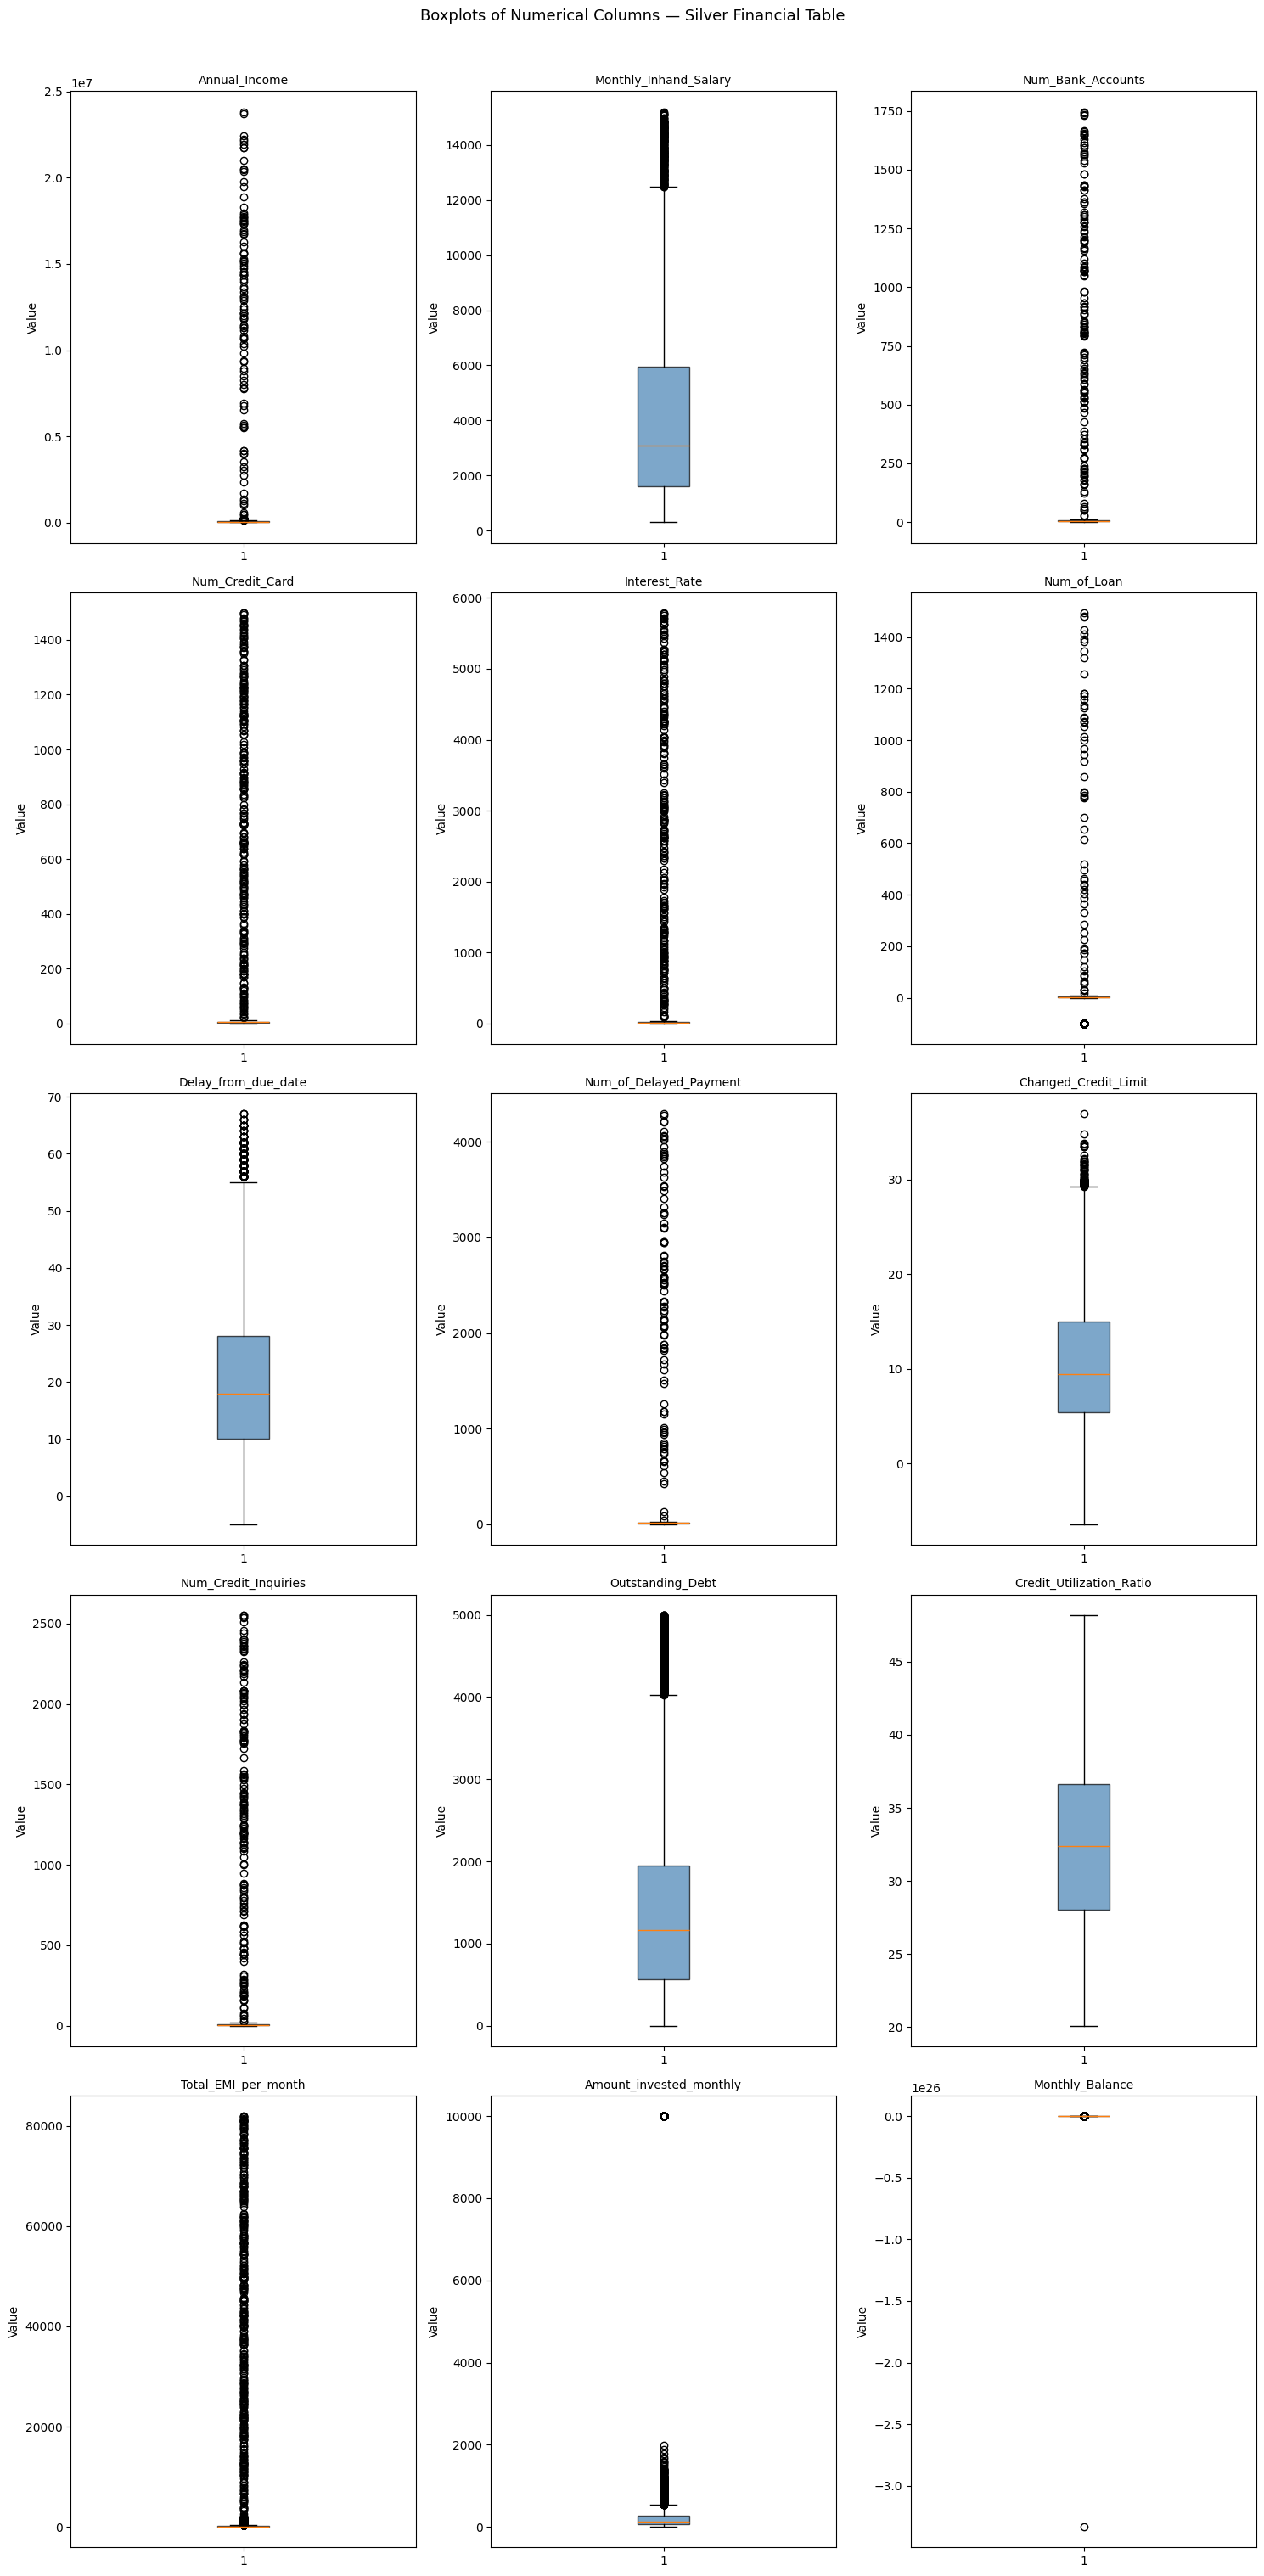

In [15]:
# Load all silver financial parquet files as a Spark DataFrame
fin_files = [silver_fin_directory + os.path.basename(f) for f in glob.glob(os.path.join(silver_fin_directory, '*.parquet'))]
fin_df = spark.read.parquet(*fin_files)

# Identify numerical columns from schema
from pyspark.sql.types import NumericType
num_cols = [f.name for f in fin_df.schema.fields if isinstance(f.dataType, NumericType)]
print("Numerical columns:", num_cols)

# Convert to pandas only for visualization
fin_pdf = fin_df.toPandas()

fig, axes = plt.subplots(5, 3, figsize=(15, 30))
axes = axes.flatten()

for i, col_name in enumerate(num_cols):
    axes[i].boxplot(fin_pdf[col_name].dropna(), vert=True, patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col_name, fontsize=10)
    axes[i].set_ylabel('Value')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots of Numerical Columns — Silver Financial Table', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Remove Negative Numbers

In [16]:
# Remove rows where any numerical column contains a negative value
print(f"Rows before negative removal: {fin_df.count()}")

filtered_df = fin_df
for col_name in num_cols:
    before = filtered_df.count()
    filtered_df = filtered_df.filter(col(col_name) >= 0)
    removed = before - filtered_df.count()
    if removed > 0:
        print(f"{col_name}: removed {removed} rows with negative values")

print(f"Rows after negative removal: {filtered_df.count()}")
filtered_df.show(5)

Rows before negative removal: 11974


Num_Bank_Accounts: removed 4 rows with negative values


Num_of_Loan: removed 486 rows with negative values


Delay_from_due_date: removed 78 rows with negative values


Num_of_Delayed_Payment: removed 81 rows with negative values


Changed_Credit_Limit: removed 419 rows with negative values


Monthly_Balance: removed 1 rows with negative values


Rows after negative removal: 10905
+-----------+-------------+---------------------+-----------------+---------------+-------------+-----------+--------------------+-------------------+----------------------+--------------------+--------------------+----------+----------------+------------------------+--------------------+---------------------+-------------------+-----------------------+--------------------+---------------+-------------+
|Customer_ID|Annual_Income|Monthly_Inhand_Salary|Num_Bank_Accounts|Num_Credit_Card|Interest_Rate|Num_of_Loan|        Type_of_Loan|Delay_from_due_date|Num_of_Delayed_Payment|Changed_Credit_Limit|Num_Credit_Inquiries|Credit_Mix|Outstanding_Debt|Credit_Utilization_Ratio|  Credit_History_Age|Payment_of_Min_Amount|Total_EMI_per_month|Amount_invested_monthly|   Payment_Behaviour|Monthly_Balance|snapshot_date|
+-----------+-------------+---------------------+-----------------+---------------+-------------+-----------+--------------------+-------------------+-

## Remove Outliers

In [17]:
# Specify which columns to apply outlier removal on
cols_to_clip = [
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Interest_Rate",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Num_Credit_Inquiries",
    "Outstanding_Debt",
    "Total_EMI_per_month",
    "Amount_invested_monthly",
    "Monthly_Balance",
]

print(f"Rows before outlier removal: {filtered_df.count()}")

for col_name in cols_to_clip:
    Q1, Q3 = filtered_df.approxQuantile(col_name, [0.25, 0.75], 0.0)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = filtered_df.count()
    filtered_df = filtered_df.filter((col(col_name) >= lower) & (col(col_name) <= upper))
    removed = before - filtered_df.count()
    print(f"  {col_name}: whiskers [{lower:.2f}, {upper:.2f}] — removed {removed} rows")

print(f"\nRows after outlier removal: {filtered_df.count()}")

Rows before outlier removal: 10905


  Annual_Income: whiskers [-60412.42, 152109.95] — removed 292 rows


  Monthly_Inhand_Salary: whiskers [-4650.10, 12021.43] — removed 87 rows


  Num_Bank_Accounts: whiskers [-2.00, 14.00] — removed 146 rows


  Num_Credit_Card: whiskers [-0.50, 11.50] — removed 256 rows


...

  Outstanding_Debt: whiskers [-1596.13, 4208.78] — removed 439 rows


  Total_EMI_per_month: whiskers [-168.84, 362.60] — removed 693 rows


  Amount_invested_monthly: whiskers [-187.11, 501.78] — removed 901 rows


  Monthly_Balance: whiskers [-2.21, 735.56] — removed 570 rows



Rows after outlier removal: 7017


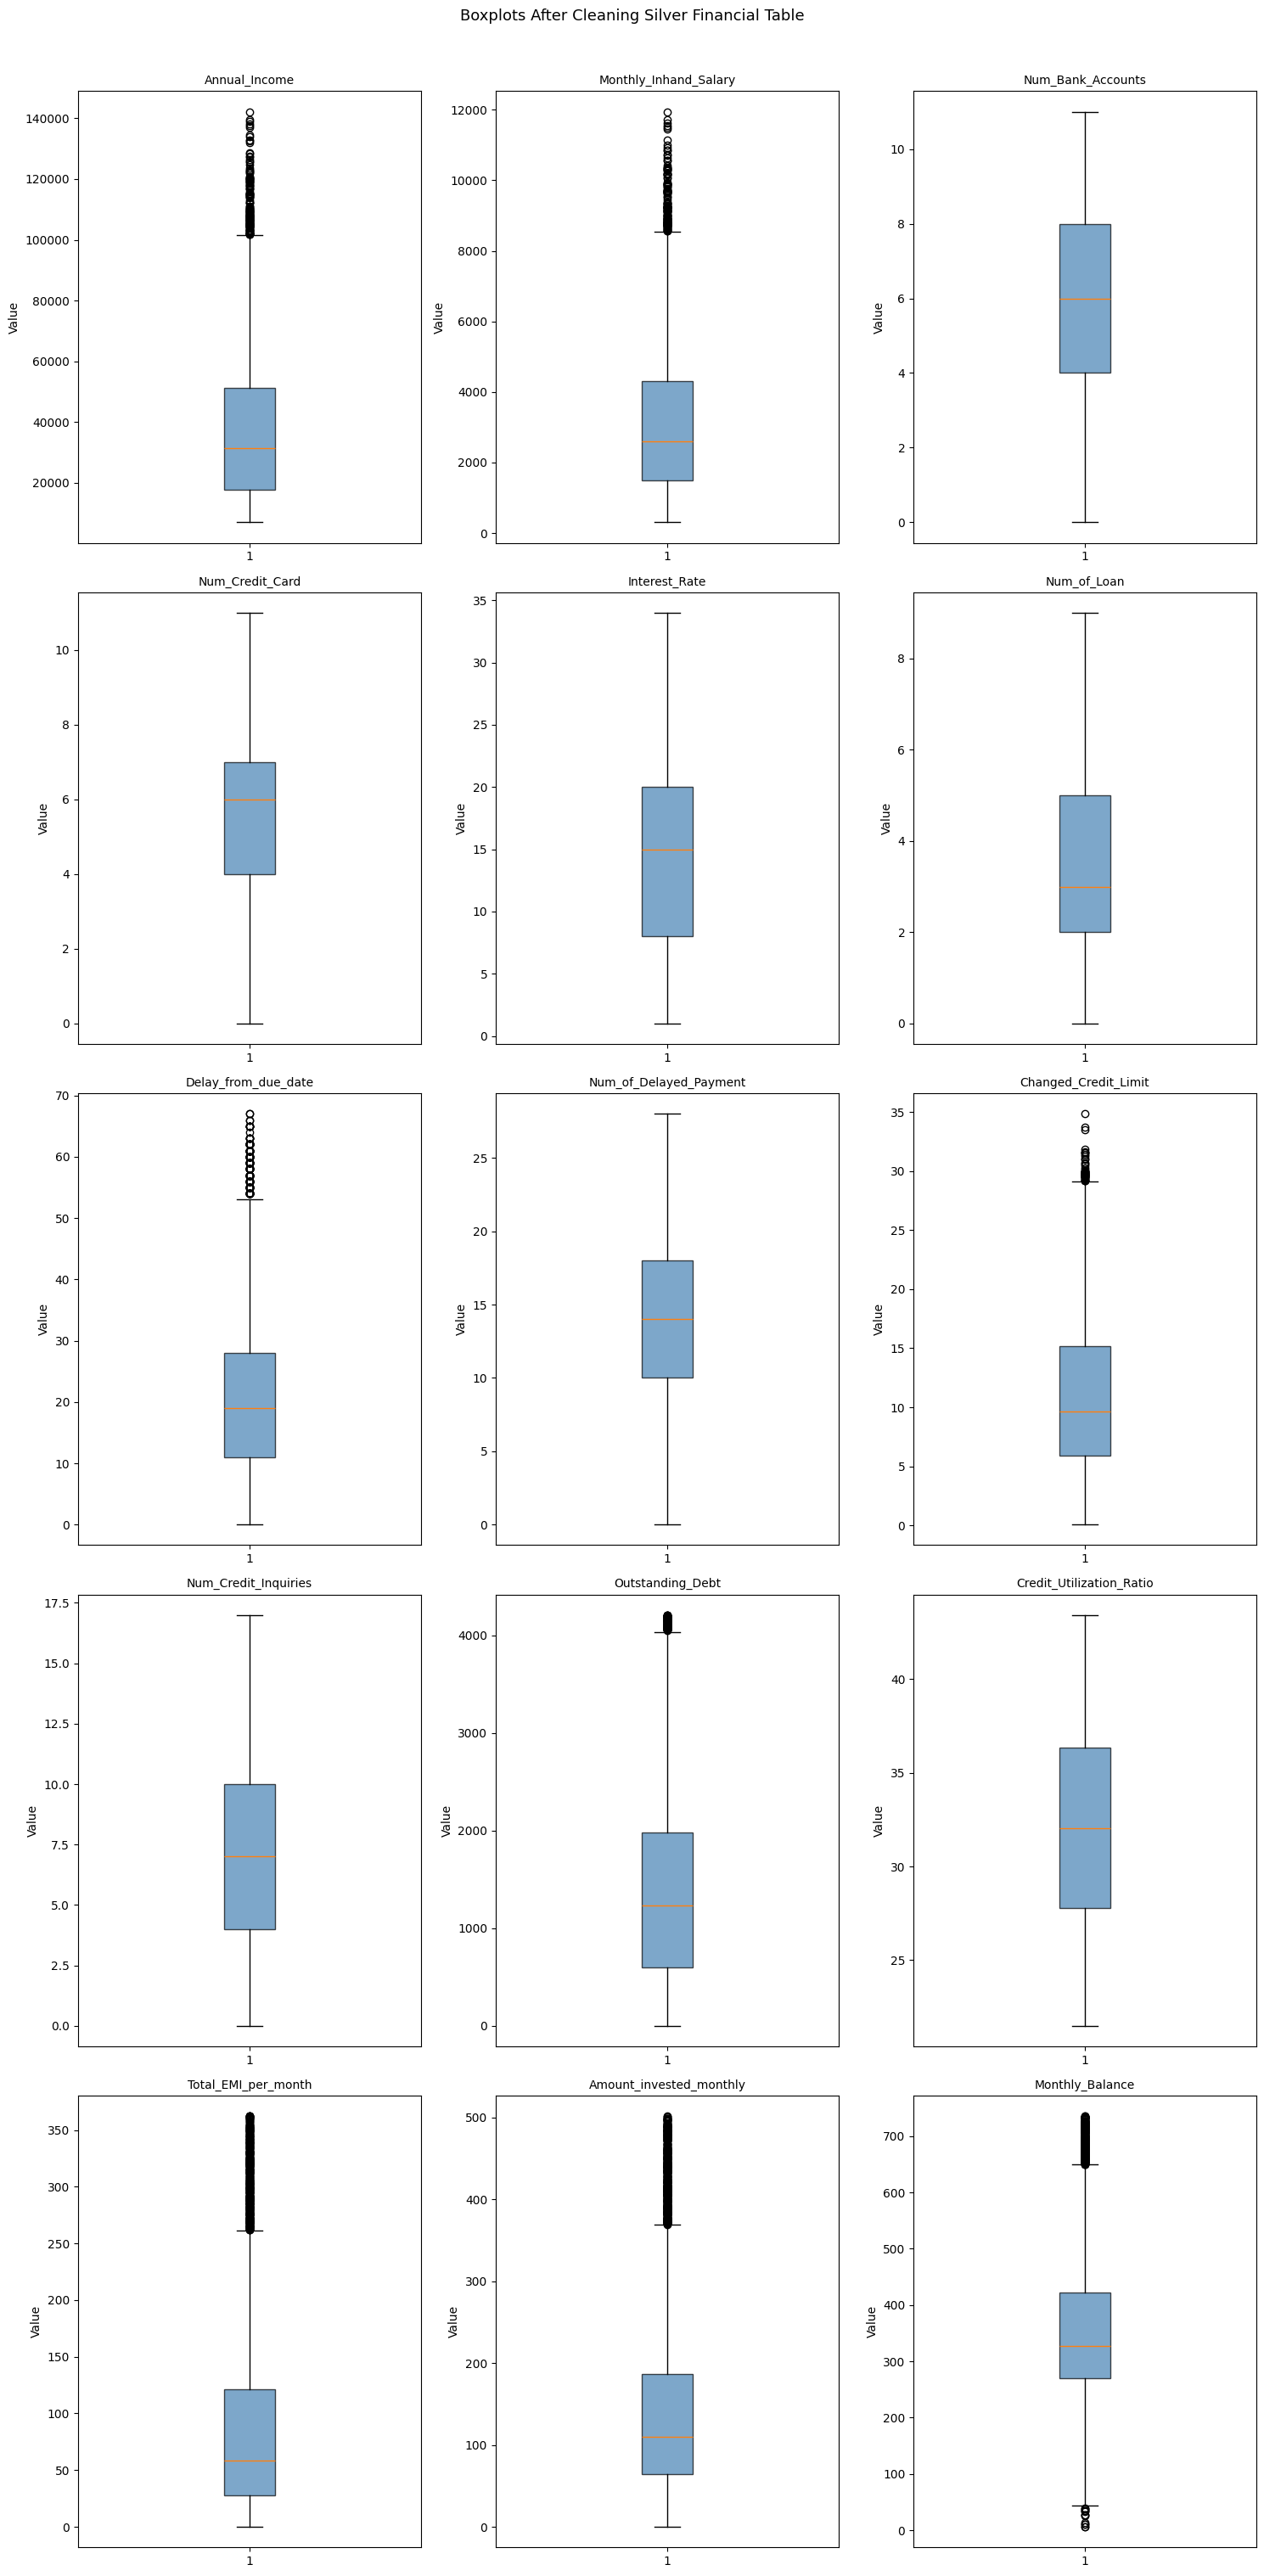

In [18]:
# Boxplot after cleaning to verify outlier and negative removal
filtered_pdf = filtered_df.toPandas()
num_cols_clean = filtered_pdf.select_dtypes(include="number").columns.tolist()

fig, axes = plt.subplots(5, 3, figsize=(15, 30))
axes = axes.flatten()

for i, col_name in enumerate(num_cols_clean):
    axes[i].boxplot(filtered_pdf[col_name].dropna(), vert=True, patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.7))
    axes[i].set_title(col_name, fontsize=10)
    axes[i].set_ylabel("Value")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots After Cleaning Silver Financial Table", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [19]:
df.show()

+-----------+-------------+---------------------+-----------------+---------------+-------------+-----------+--------------------+-------------------+----------------------+--------------------+--------------------+----------+----------------+------------------------+--------------------+---------------------+-------------------+-----------------------+--------------------+---------------+-------------+
|Customer_ID|Annual_Income|Monthly_Inhand_Salary|Num_Bank_Accounts|Num_Credit_Card|Interest_Rate|Num_of_Loan|        Type_of_Loan|Delay_from_due_date|Num_of_Delayed_Payment|Changed_Credit_Limit|Num_Credit_Inquiries|Credit_Mix|Outstanding_Debt|Credit_Utilization_Ratio|  Credit_History_Age|Payment_of_Min_Amount|Total_EMI_per_month|Amount_invested_monthly|   Payment_Behaviour|Monthly_Balance|snapshot_date|
+-----------+-------------+---------------------+-----------------+---------------+-------------+-----------+--------------------+-------------------+----------------------+-------------

## Save Cleaned Financial Data to Silver

In [20]:
# Save cleaned financial data back to silver directory, one file per snapshot_date
# Cache first to break lineage dependency on source files before overwriting them
filtered_df.cache()
filtered_df.count()

date_strs = sorted([row["snapshot_date"] for row in filtered_df.select("snapshot_date").distinct().collect()])

for date_str in date_strs:
    date_formatted = str(date_str).replace("-", "_")
    out_path = silver_fin_directory + f"silver_financial_{date_formatted}.parquet"
    filtered_df.filter(col("snapshot_date") == date_str).write.mode("overwrite").parquet(out_path)
    print(f"saved to: {out_path}")

filtered_df.unpersist()

saved to: datamart/silver/financial/silver_financial_2023_01_01.parquet


saved to: datamart/silver/financial/silver_financial_2023_02_01.parquet


saved to: datamart/silver/financial/silver_financial_2023_03_01.parquet


saved to: datamart/silver/financial/silver_financial_2023_04_01.parquet


saved to: datamart/silver/financial/silver_financial_2023_05_01.parquet


...

saved to: datamart/silver/financial/silver_financial_2024_09_01.parquet


saved to: datamart/silver/financial/silver_financial_2024_10_01.parquet


saved to: datamart/silver/financial/silver_financial_2024_11_01.parquet


saved to: datamart/silver/financial/silver_financial_2024_12_01.parquet


DataFrame[Customer_ID: string, Annual_Income: float, Monthly_Inhand_Salary: float, Num_Bank_Accounts: int, Num_Credit_Card: int, Interest_Rate: int, Num_of_Loan: int, Type_of_Loan: string, Delay_from_due_date: int, Num_of_Delayed_Payment: int, Changed_Credit_Limit: float, Num_Credit_Inquiries: int, Credit_Mix: string, Outstanding_Debt: float, Credit_Utilization_Ratio: float, Credit_History_Age: string, Payment_of_Min_Amount: string, Total_EMI_per_month: float, Amount_invested_monthly: float, Payment_Behaviour: string, Monthly_Balance: float, snapshot_date: date]

In [21]:
# Verify saved parquet files match the cleaned DataFrame
verify_files = [silver_fin_directory + os.path.basename(f) for f in glob.glob(os.path.join(silver_fin_directory, '*.parquet'))]
verify_df = spark.read.parquet(*verify_files)

total_saved = verify_df.count()
total_cleaned = filtered_df.count()
print(f"Total rows in saved parquet: {total_saved}")
print(f"Total rows in filtered_df:   {total_cleaned}")
print(f"Row counts match: {total_saved == total_cleaned}")
print()

# Check no negatives in numerical columns
print("Negative value check (should all be 0):")
for col_name in cols_to_clip:
    neg_count = verify_df.filter(col(col_name) < 0).count()
    print(f"  {col_name}: {neg_count} negative rows")

print()
verify_df.show(5)

Total rows in saved parquet: 7017
Total rows in filtered_df:   7017
Row counts match: True

Negative value check (should all be 0):


  Annual_Income: 0 negative rows


  Monthly_Inhand_Salary: 0 negative rows


  Num_Bank_Accounts: 0 negative rows


  Num_Credit_Card: 0 negative rows


...

  Num_Credit_Inquiries: 0 negative rows


  Outstanding_Debt: 0 negative rows


  Total_EMI_per_month: 0 negative rows


  Amount_invested_monthly: 0 negative rows


  Monthly_Balance: 0 negative rows

+-----------+-------------+---------------------+-----------------+---------------+-------------+-----------+--------------------+-------------------+----------------------+--------------------+--------------------+----------+----------------+------------------------+--------------------+---------------------+-------------------+-----------------------+--------------------+---------------+-------------+
|Customer_ID|Annual_Income|Monthly_Inhand_Salary|Num_Bank_Accounts|Num_Credit_Card|Interest_Rate|Num_of_Loan|        Type_of_Loan|Delay_from_due_date|Num_of_Delayed_Payment|Changed_Credit_Limit|Num_Credit_Inquiries|Credit_Mix|Outstanding_Debt|Credit_Utilization_Ratio|  Credit_History_Age|Payment_of_Min_Amount|Total_EMI_per_month|Amount_invested_monthly|   Payment_Behaviour|Monthly_Balance|snapshot_date|
+-----------+-------------+---------------------+-----------------+---------------+-------------+-----------+--------------------+-------------------+